In [1]:
import pandas as pd
# import utils as uti
from utils import results as res
import matplotlib.pyplot as plt
import pickle

In [2]:
df_train = pd.read_pickle("../data/01_df_train.pkl")
df_test = pd.read_pickle("../data/01_df_test.pkl")

In [3]:
walds = pd.read_pickle("../data/01_df_walds.pkl")

In [4]:
with open("../data/02_dic_models.pkl", "rb") as file:
    models = pickle.load(file)

In [5]:
walds.head()

,var,auc,corr,corr ind
0,checking_account_status_woe,0.700714,0.228923,False
1,credit_history_woe,0.641429,0.414942,True
2,purpose_woe,0.609829,0.137224,False
3,savings_account_bonds_woe,0.607543,0.228923,False
4,duration_months_woe,0.602352,0.181447,False


In [6]:
models.keys()

dict_keys(['xgb woe', 'logi', 'xgb raw'])

# predict logistic

In [7]:
import statsmodels.api as sm

In [8]:
models['logi'].params.index.tolist()[1:]

['checking_account_status_woe',
 'duration_months_woe',
 'purpose_woe',
 'savings_account_bonds_woe',
 'other_installment_plans_woe',
 'credit_amount_woe',
 'employment_since_woe',
 'installment_rate_percent_woe',
 'property_woe']

In [9]:
tmp = sm.add_constant(
    df_train[models['logi'].params.index.tolist()[1:]],
    has_constant="add"
)

df_train['logi'] = models['logi'].predict(tmp)

In [10]:
tmp = sm.add_constant(
    df_test[models['logi'].params.index.tolist()[1:]],
    has_constant="add"
)

df_test['logi'] = models['logi'].predict(tmp)

# predict XGB WoE

In [11]:
df_train['xgb woe'] = models['xgb woe'].predict_proba(df_train[models['xgb woe'].get_booster().feature_names])[:, 1]

In [12]:
df_test['xgb woe'] = models['xgb woe'].predict_proba(df_test[models['xgb woe'].get_booster().feature_names])[:, 1]

# predict XGB raw

## onehot data

In [13]:
import joblib

preprocessor = joblib.load("../data/02b_dummy_preprocessor.pkl")

In [14]:
train_array = preprocessor.transform(df_train)
test_array = preprocessor.transform(df_test)

In [15]:
pre_names = preprocessor.get_feature_names_out()

X_train = pd.DataFrame(
    train_array,
    columns=pre_names,
    index=df_train.index
)

In [16]:
pre_names = preprocessor.get_feature_names_out()

X_test = pd.DataFrame(
    test_array,
    columns=pre_names,
    index=df_test.index
)

In [17]:
df_train['xgb raw'] = models['xgb raw'].predict_proba(X_train[models['xgb raw'].get_booster().feature_names])[:, 1]

In [18]:
df_test['xgb raw'] = models['xgb raw'].predict_proba(X_test[models['xgb raw'].get_booster().feature_names])[:, 1]

# perfect prediction

In [19]:
df_train.sort_values(by='bad', inplace= True)
df_train['perf'] = range(len(df_train))

In [20]:
df_test.sort_values(by='bad', inplace=True)
df_test['perf'] = range(len(df_test))

# compare performance

In [21]:
df_train.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,employment_since,installment_rate_percent,personal_status_sex,other_debtors_guarantors,...,savings_account_bonds_woe,employment_since_woe,property_woe,other_installment_plans_woe,housing_woe,telephone_woe,logi,xgb woe,xgb raw,perf
121,no account,24,critical or other credit,used car,3868,lt100 DM,ge7 years,4,female married or divorced,none,...,0.311336,-0.310155,-0.002692,-0.162649,0.580669,-0.112478,0.025299,0.054773,0.089982,0
256,no account,24,critical or other credit,radio or TV,2684,lt100 DM,1 to 4 years,4,male single,none,...,0.311336,-0.023056,-0.400846,-0.162649,-0.215209,0.069312,0.113794,0.062829,0.083112,1
12,0 to 200 DM,12,current credit paid,radio or TV,1567,lt100 DM,1 to 4 years,1,female married or divorced,none,...,0.311336,-0.023056,-0.002692,-0.162649,-0.215209,-0.112478,0.181252,0.238845,0.248568,2
207,0 to 200 DM,12,critical or other credit,appliances,1424,lt100 DM,4 to 7 years,4,male single,none,...,0.311336,-0.430363,0.026317,-0.162649,-0.215209,0.069312,0.148257,0.096681,0.172610,3
32,0 to 200 DM,18,current credit paid,new car,5866,100 to 500 DM,1 to 4 years,2,male single,none,...,-0.068993,-0.023056,-0.002692,-0.162649,-0.215209,-0.112478,0.345898,0.249798,0.234534,4


In [22]:
df_test.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,employment_since,installment_rate_percent,personal_status_sex,other_debtors_guarantors,...,savings_account_bonds_woe,employment_since_woe,property_woe,other_installment_plans_woe,housing_woe,telephone_woe,logi,xgb woe,xgb raw,perf
52,no account,12,current credit paid,radio or TV,1262,lt100 DM,1 to 4 years,3,male single,none,...,0.311336,-0.023056,-0.002692,-0.162649,-0.215209,0.069312,0.096416,0.070192,0.087113,0
671,no account,36,current credit paid,business,5742,100 to 500 DM,4 to 7 years,2,male single,none,...,-0.068993,-0.430363,-0.002692,-0.162649,-0.215209,-0.112478,0.145176,0.090386,0.125146,1
786,no account,22,current credit paid,radio or TV,2675,500 to 1000 DM,ge7 years,3,male single,none,...,-0.778669,-0.310155,-0.002692,-0.162649,-0.215209,0.069312,0.040061,0.047962,0.080826,2
7,0 to 200 DM,36,current credit paid,used car,6948,lt100 DM,1 to 4 years,2,male single,none,...,0.311336,-0.023056,-0.002692,-0.162649,0.580669,-0.112478,0.256758,0.447246,0.447775,3
896,lt0 DM,21,current credit paid,radio or TV,2606,lt100 DM,lt1 year,4,female married or divorced,none,...,0.311336,0.495900,0.026317,-0.162649,0.580669,-0.112478,0.603556,0.817765,0.774203,4


In [23]:
models_names = {
    "Logistic regression": "logi",
    "XGBoost WoE": "xgb woe",
    "XGBoost": "xgb raw",
    "Perfect": "perf"    
}

## ROC

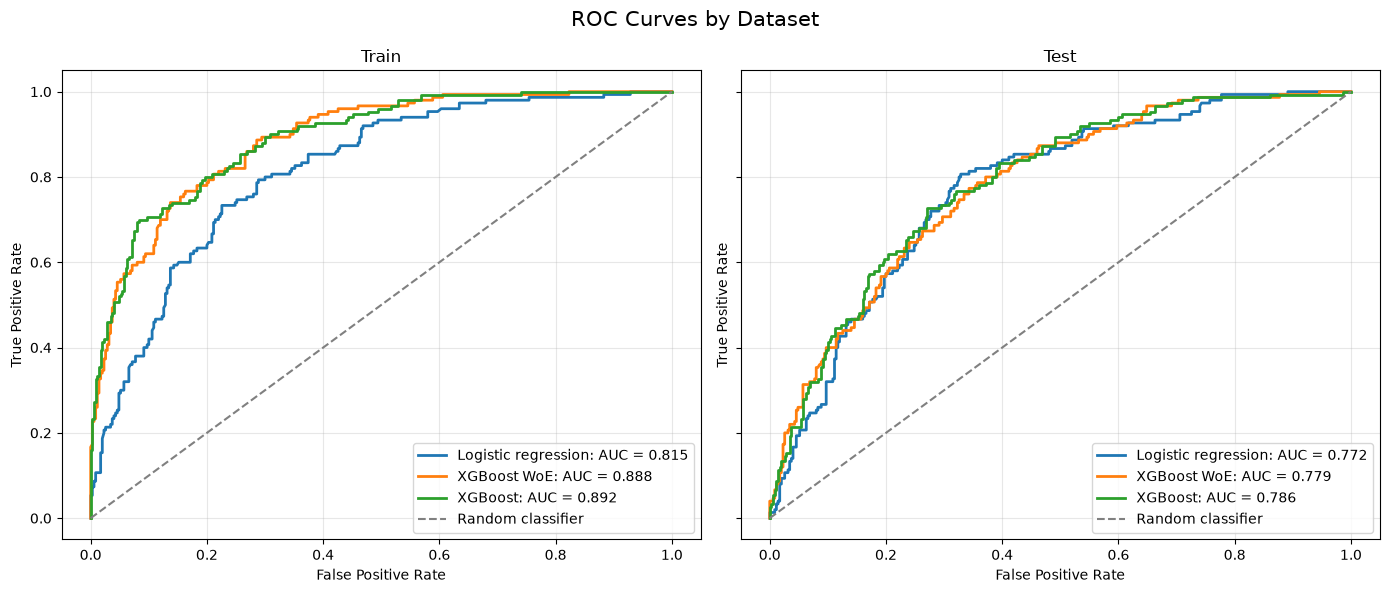

In [24]:
res.roc_plot(
    df_1=df_train,
    df_2=df_test,
    models=dict(list(models_names.items())[:-1]),
    target_name="bad"
)

## Lift

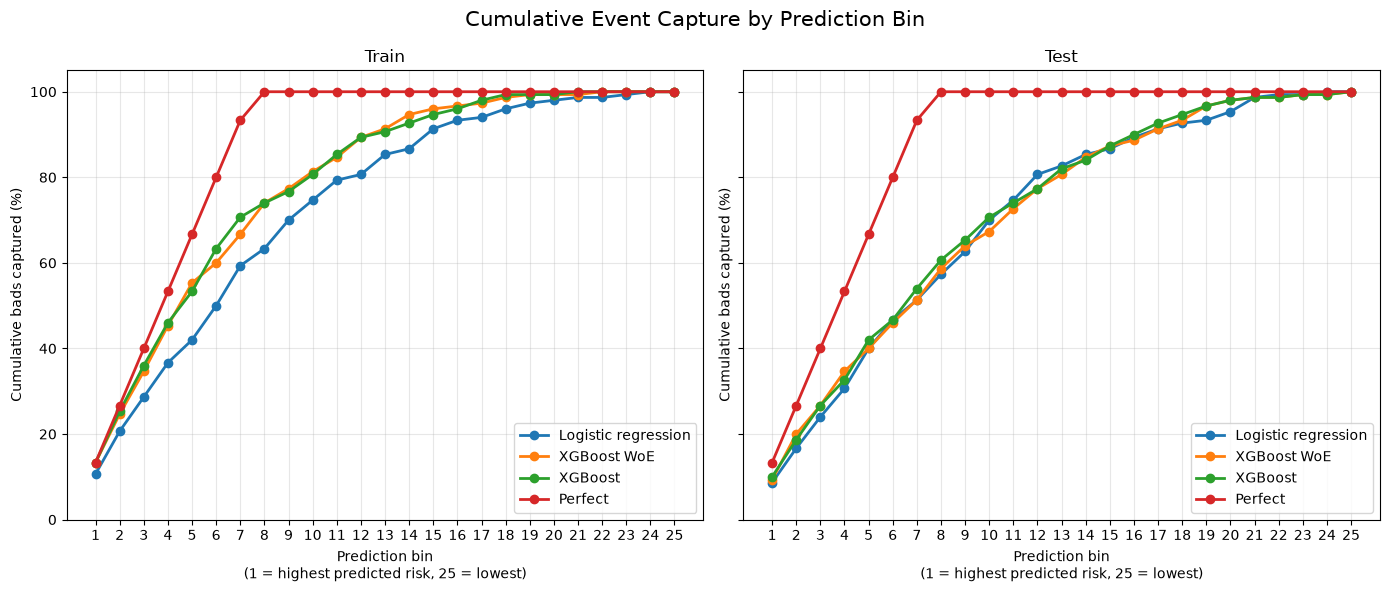

In [25]:
res.cumulative_event_rate_plot(
    df_1=df_train,
    df_2=df_test,
    models=models_names,
    target_name="bad",
    n_bins=25
)

## KS

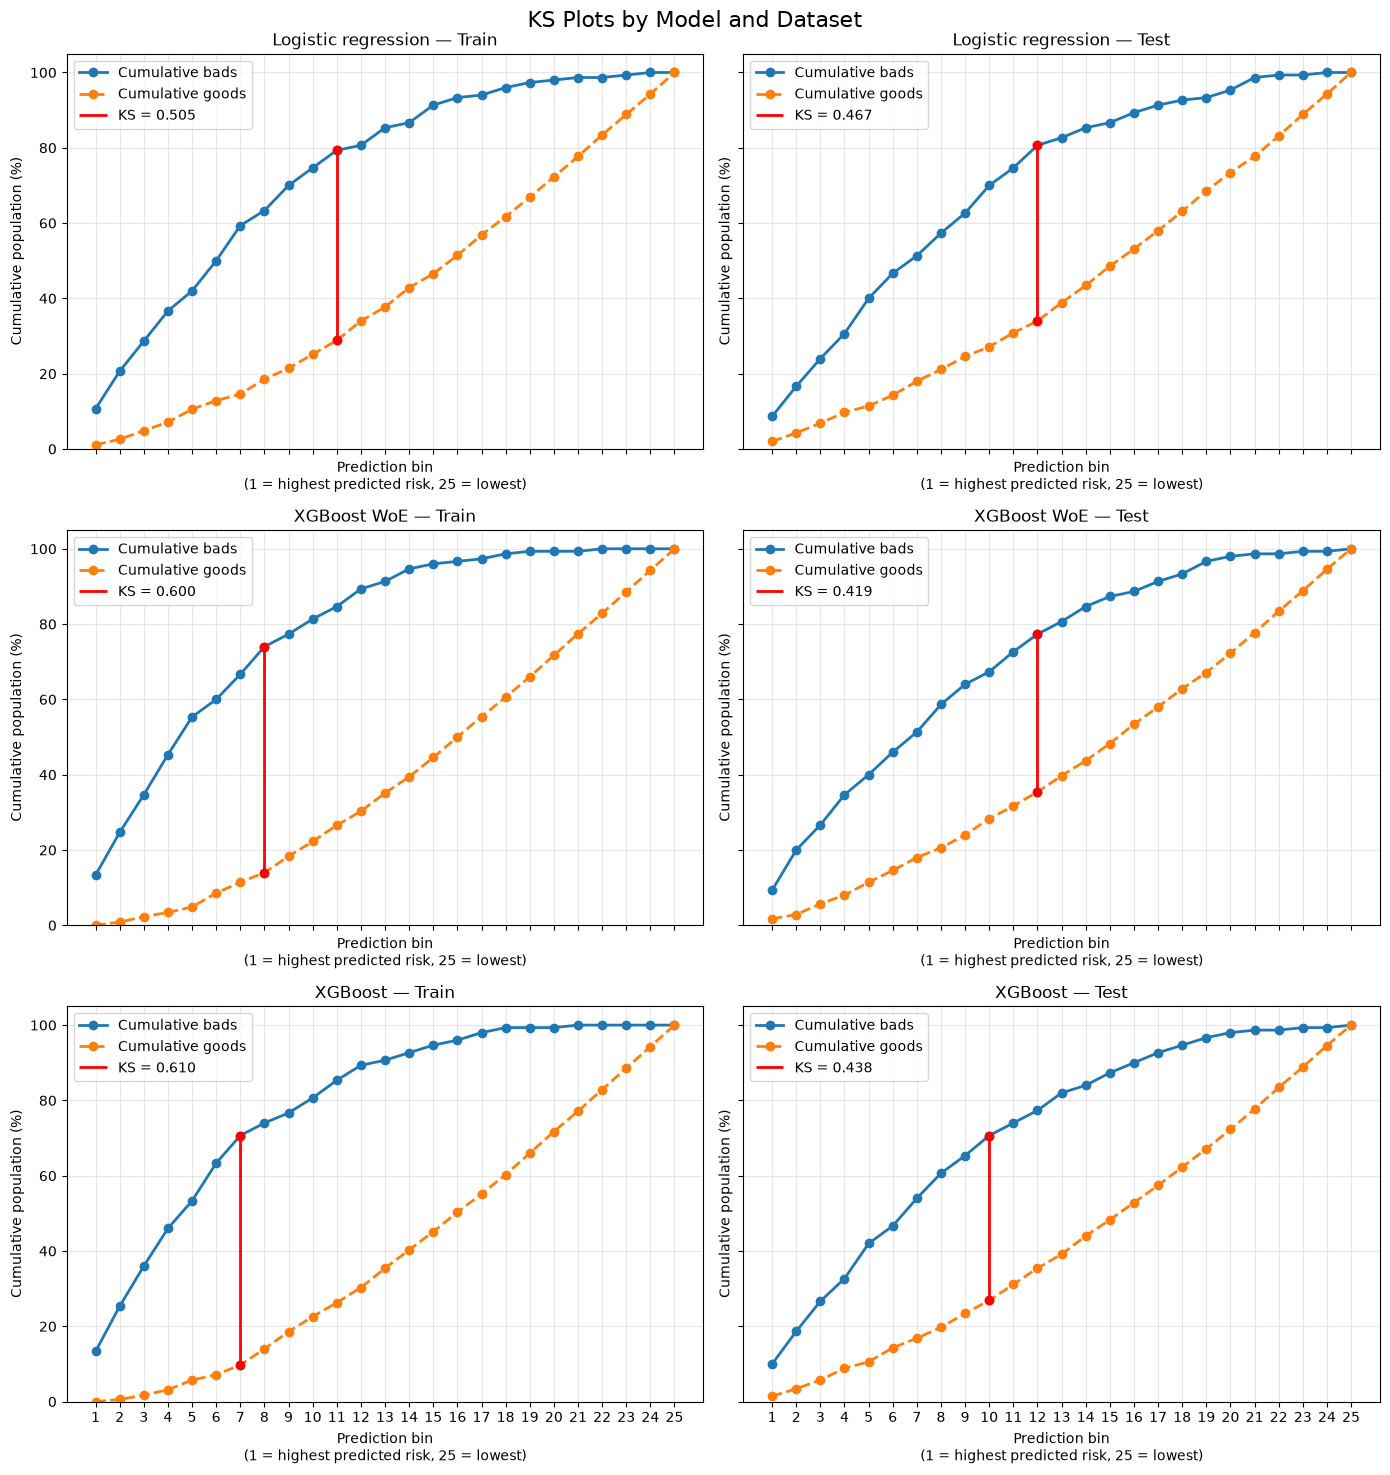

In [26]:
res.ks_plot(
    df_1=df_train,
    df_2=df_test,
    models=dict(list(models_names.items())[:-1]),
    target_name="bad",
    n_bins=25
)

# calibration

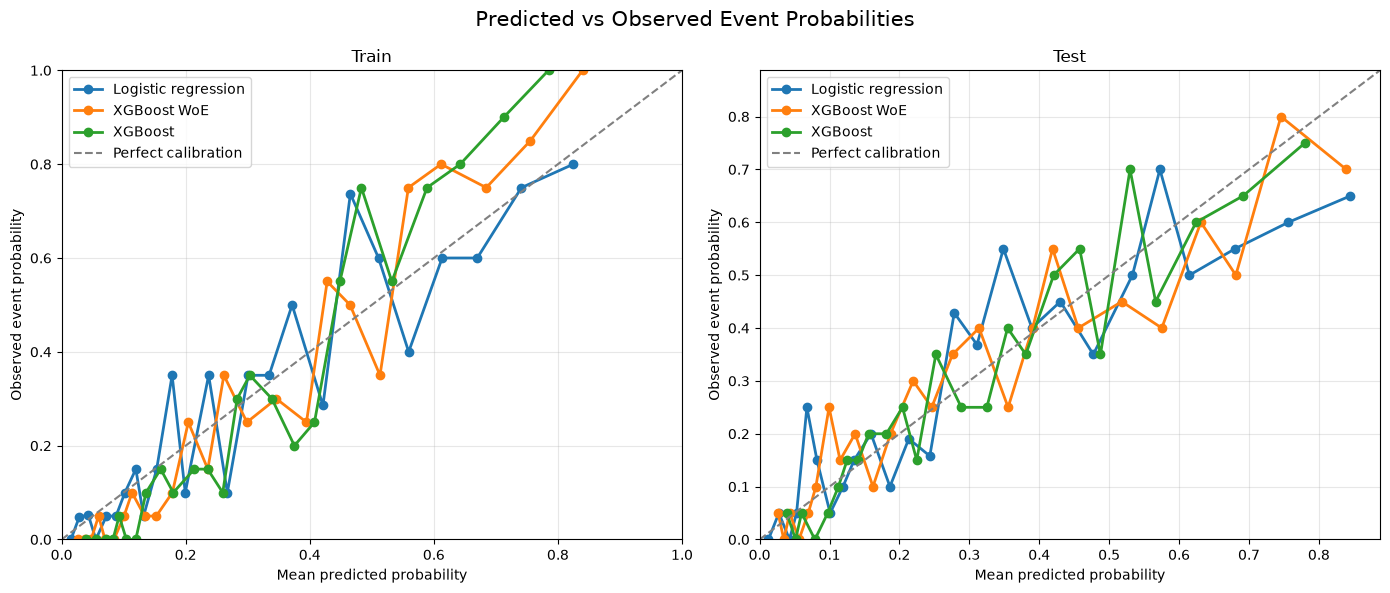

In [27]:
res.calibration_plot(
    df_1=df_train,
    df_2=df_test,
    models=dict(list(models_names.items())[:-1]),
    target_name="bad",
    n_bins=25
)

# save predictions

In [28]:
df_train['sample'] = 'train'
df_test['sample'] = 'test'

In [29]:
results = pd.concat(
    [df_train, df_test],
    ignore_index=True
)

In [30]:
results.to_pickle("../data/03_df_results_df.pkl")